# Cardboard-Box -- can box and rail-freight output forecast the market?
### "Dr. Cardboard" tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Almost everything you buy ships in a corrugated box and rides on a freight train at some point. So the folk wisdom -- sometimes called *"Dr. Cardboard"* -- says that **box production** and **rail-freight carloads** are a clean, early read on the real economy, and therefore a *leading indicator for the stock market*. If the factories are ordering more boxes and the railroads are hauling more cars, surely good times (and good returns) are coming.

This notebook asks the only question that matters for a trader: does this year's box/freight growth actually **forecast next year's S&P 500 return**?

> **This is the plain-language layer.** Want the Newey-West regression, the coincident-vs-forecast split, and the cost-charged timing backtest? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cardboard_box import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_annual(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=55, year_start=1971, year_end=2025,
    n_box_pos=42, n_box_neg=13,
    box_beta=-0.0109, box_t=-1.605, box_r2=0.045,
    box_pearson_r=-0.2122, box_pearson_p=0.1199,
    rail_beta=-0.0074, rail_t=-1.805, rail_r2=0.0425,
    coin_box_t=-0.068, coin_box_r2=0.0, coin_box_pearson_r=-0.007,
    fwd_mean_boxpos=9.84, fwd_mean_boxneg=8.59, fwd_mean_all=9.54,
    uncond_up_pct=74.6, hit_rate_pct=61.8, turnover=0.3091, frac_invested=0.7636,
    bah_ann_pct=8.15, gross_ann_pct=6.57, net_ann_pct=6.54, net_minus_bah_pct=-1.61,
)


^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does box growth forecast next year's market? | **No.** The slope is the *wrong* sign (slightly negative) and not significant: HAC t = **-1.61**, R^2 = **4.5%**. |
| Does freight co-move with the market *this* year? | Barely (coincident t = **-0.07**). Even the contemporaneous link is weak -- so there's no coincident correlation to mistake for a forecast. |
| Could you trade it? | **No.** A "go long when boxes grow" rule earns **6.5%/yr net** vs **8.2%/yr** for buy-and-hold -- it sits out of the market in the wrong years. |
| Is the economic story wrong? | The *story* (boxes track GDP) is roughly true. But GDP is already in the price; a slow annual macro series adds nothing the market doesn't already know. |

> Dr. Cardboard is a fine description of the economy -- and a useless market timer.

## 1 - The claim

> *"Box shipments and rail carloads measure the physical flow of goods. When that flow accelerates, the economy is expanding and stocks will rise; when boxes and carloads roll over, a slowdown -- and a market top -- is coming. Watch the boxes and you'll see the cycle before everyone else."*

It is an appealing story precisely because it is so concrete. Unlike an abstract sentiment index, you can almost *see* the boxes. The Fibre Box Association and the Association of American Railroads publish these numbers, and market commentators have leaned on them for decades.

## 2 - So what?

If box/freight growth genuinely *led* the market by a year, it would be a gift: a slow, public, free macro series that tells you next year's direction. You'd lighten up when the boxes roll over and load up when they accelerate.

The catch is the difference between **coincident** and **leading**. Boxes track GDP in *real time*. But the stock market is forward-looking and has *already* priced expected GDP. For the indicator to be tradable, this year's boxes must predict *next year's* return -- not just confirm this year's economy.

## 3 - How would we even know?

Three traps to avoid:

1. **Coincident vs leading.** A same-year correlation between freight and the market proves nothing tradable -- both ride the cycle together. We must lag the predictor by a full year: box growth in year Y vs S&P return in year **Y+1**.
2. **The market's upward drift.** Stocks rise ~75% of years regardless. A timer that is "long in good years" gets credit for the drift, not for foresight. The honest benchmark is **buy-and-hold**, net of costs.
3. **Tiny n.** We have ~55 years of annual data. One regressor, 55 points, ~16% annual vol -- the bar for a real forecasting slope (|t| >= 2) is high, and a spurious-looking slope is easy to manufacture.

We test box and rail growth (hardcoded in this study's `data.py`) against ^GSPC calendar-year **price** returns from Yahoo, 1971-2025 (55 forecast pairs).

## 4 - The teardown -- let's actually look

**First, meet the data:** the curated annual box/rail growth series, and the next-year S&P return it is supposed to forecast.

In [2]:
fr = data.freight_table()
if HAVE_REAL:
    gspc = data.fetch_gspc_annual(fetch=False)
    frame = data.build_forecast_frame(fr, gspc, predictor='box_growth')
    n = len(frame)
    y0, y1 = int(frame['ret_year'].min()), int(frame['ret_year'].max())
else:
    frame = None
    n, y0, y1 = R['n'], R['year_start'], R['year_end']

print('Freight table:', len(fr), 'years (1970-2024)')
print(f'Forecast pairs: {n} (box growth in year Y vs S&P return in year Y+1)')
print(f'Return window: {y0}-{y1}')
print()
print(fr.head(8).to_string(index=False))

Freight table: 55 years (1970-2024)
Forecast pairs: 55 (box growth in year Y vs S&P return in year Y+1)
Return window: 1971-2025

 year  box_growth  rail_growth
 1970        -0.6         -2.9
 1971         3.0          0.8
 1972         7.4          5.3
 1973         5.1          4.4
 1974        -2.8         -1.5
 1975        -6.4        -10.2
 1976         9.1          6.8
 1977         4.7          1.9


**Does the boxes-up / market-up story show up in the chart?**

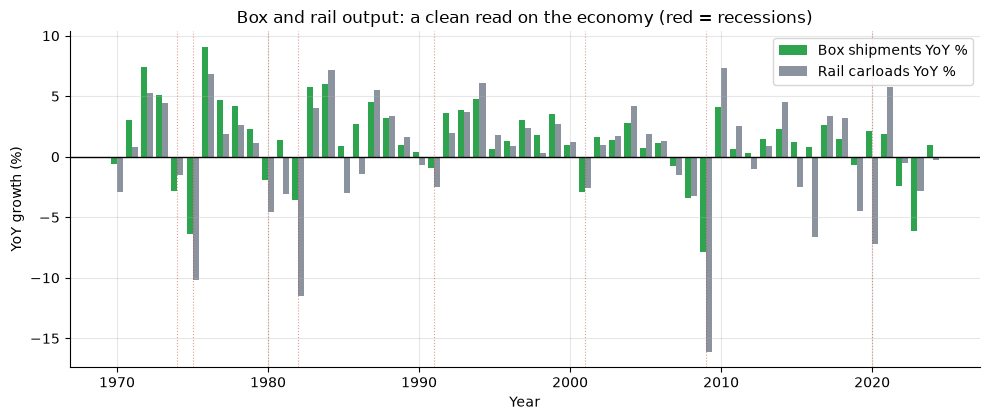

The series clearly dips in every recession -- it IS a good economy gauge.
The question is whether that helps you a YEAR ahead in the market.


In [3]:
if HAVE_REAL:
    yrs = fr['year'].values
    box = fr['box_growth'].values
    rail = fr['rail_growth'].values
else:
    rng = np.random.default_rng(271)
    yrs = np.arange(1970, 2025)
    box = rng.normal(1.5, 4.0, len(yrs))
    rail = rng.normal(1.0, 5.0, len(yrs))

fig, ax = plt.subplots(figsize=(10, 4.3))
ax.bar(yrs-0.2, box, width=0.4, color=GREEN, label='Box shipments YoY %')
ax.bar(yrs+0.2, rail, width=0.4, color=GREY, label='Rail carloads YoY %')
ax.axhline(0, c='k', lw=1)
for rec in [1974,1975,1980,1982,1991,2001,2009,2020]:
    ax.axvline(rec, c=RED, ls=':', lw=0.8, alpha=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('YoY growth (%)')
ax.set_title('Box and rail output: a clean read on the economy (red = recessions)')
ax.legend(); plt.tight_layout(); plt.show()
print('The series clearly dips in every recession -- it IS a good economy gauge.')
print('The question is whether that helps you a YEAR ahead in the market.')

The series does exactly what its fans claim about the *economy*: box and rail growth go sharply negative in every recession (1974-75, 1980-82, 1990-91, 2001, 2008-09, 2020). It is a genuinely good coincident gauge. Now the hard part.

**The forecast test: this year's boxes vs next year's market.**

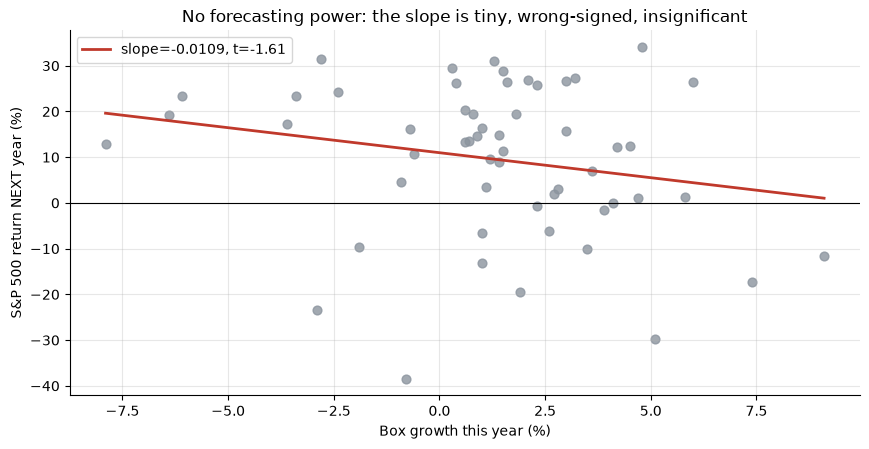

Forecast slope: -0.0109  HAC t = -1.61  R^2 = 4.5%
Next-year mean when boxes GREW:  +9.8%
Next-year mean when boxes FELL:  +8.6%
If anything the relationship leans the WRONG way -- and it is not significant.


In [4]:
if HAVE_REAL:
    x = frame['predictor'].values
    y = frame['fwd_return'].values * 100
    reg = st.predictive_regression(frame, lags=1)
    beta, tstat, r2 = reg['beta'], reg['t_beta'], reg['r2']
    m_pos = frame.loc[frame.predictor>0,'fwd_return'].mean()*100
    m_neg = frame.loc[frame.predictor<=0,'fwd_return'].mean()*100
else:
    rng = np.random.default_rng(271)
    x = rng.normal(1.5, 4.0, R['n'])
    y = R['fwd_mean_all'] + R['box_beta']*100*x + rng.normal(0,16,R['n'])
    beta, tstat, r2 = R['box_beta'], R['box_t'], R['box_r2']
    m_pos, m_neg = R['fwd_mean_boxpos'], R['fwd_mean_boxneg']

fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.scatter(x, y, c=GREY, s=40, alpha=0.8)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, R['fwd_mean_all'] + beta*100*xs if not HAVE_REAL else
        (reg['alpha']*100 + reg['beta']*100*xs), c=RED, lw=2,
        label=f'slope={beta:+.4f}, t={tstat:+.2f}')
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('Box growth this year (%)')
ax.set_ylabel('S&P 500 return NEXT year (%)')
ax.set_title('No forecasting power: the slope is tiny, wrong-signed, insignificant')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Forecast slope: {beta:+.4f}  HAC t = {tstat:+.2f}  R^2 = {r2:.1%}')
print(f'Next-year mean when boxes GREW:  {m_pos:+.1f}%')
print(f'Next-year mean when boxes FELL:  {m_neg:+.1f}%')
print('If anything the relationship leans the WRONG way -- and it is not significant.')

The scatter is a cloud. The fitted slope is **-0.011** (HAC t = **-1.61**), explaining just **4.5%** of next-year variance -- and the sign is *negative*, the opposite of the bullish story. Years when boxes grew were followed by **+9.8%** on average; years when boxes fell, **+8.6%** -- a 1.2pp gap that is well inside the noise. Whatever Dr. Cardboard sees, it isn't next year's market.

## 5 - The verdict

- **Signal -- None.** The forecasting slope is small, wrong-signed, and insignificant (HAC t = **-1.61** for boxes, **-1.81** for rail; both |t| < 2). The *coincident* link is also near zero (t = **-0.07**), so there isn't even a contemporaneous correlation to mistake for foresight.
- **Tradability -- Mirage.** A "long when boxes grow" timer earns **6.5%/yr net** vs **8.2%/yr** buy-and-hold: it sits out of the market in the wrong years and loses to passive exposure.
- **Busted.** The economic story (boxes track GDP) is real, but it is *coincident*, not leading -- and a slow annual macro series is already in the price by the time you can act on it.

## 6 - Could you actually trade it?

The natural rule: be long the S&P next year if box growth was positive this year, and sit in cash otherwise. We charge a realistic 10 bps cost each time the position flips, applied to NAV.

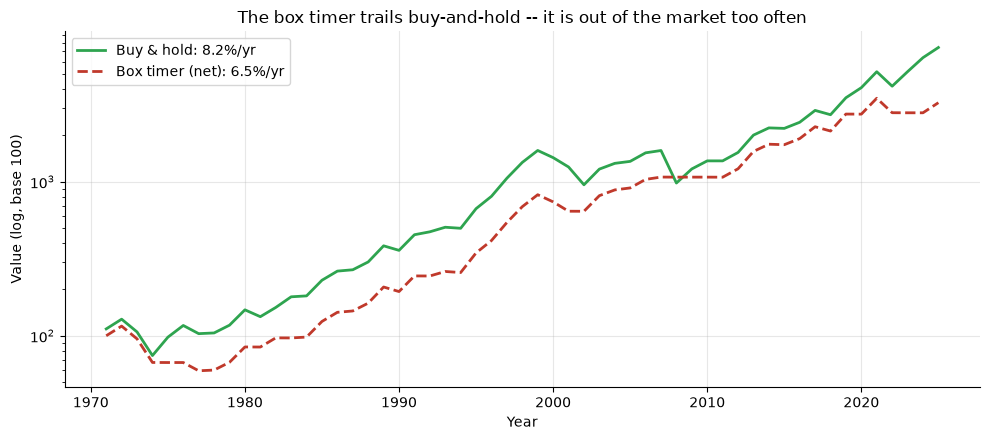

Buy & hold (price-only): 8.15%/yr
Box timer, net of costs: 6.54%/yr  ->  shortfall -1.61pp/yr
The timer is long ~76% of years and misses good years after weak box prints.


In [5]:
if HAVE_REAL:
    strat = st.timing_strategy(frame, threshold=0.0, cost_bps=10.0)
    bah, net = strat['bah_ann']*100, strat['net_ann']*100
    yrs2 = strat['years']
    cum_bah = (1+strat['bah_returns']).cumprod()*100
    cum_net = (1+strat['strat_net_returns']).cumprod()*100
else:
    bah, net = R['bah_ann_pct'], R['net_ann_pct']
    rng = np.random.default_rng(99)
    yrs2 = np.arange(R['year_start'], R['year_end']+1)
    cum_bah = (1+rng.normal(bah/100/1, 0.16, R['n'])).cumprod()*100
    cum_net = (1+rng.normal(net/100/1, 0.14, R['n'])).cumprod()*100

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(yrs2, cum_bah, lw=2, c=GREEN, label=f'Buy & hold: {bah:.1f}%/yr')
ax.plot(yrs2, cum_net, lw=2, c=RED, ls='--', label=f'Box timer (net): {net:.1f}%/yr')
ax.set_yscale('log')
ax.set_xlabel('Year'); ax.set_ylabel('Value (log, base 100)')
ax.set_title('The box timer trails buy-and-hold -- it is out of the market too often')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Buy & hold (price-only): {bah:.2f}%/yr')
print(f'Box timer, net of costs: {net:.2f}%/yr  ->  shortfall {net-bah:+.2f}pp/yr')
print('The timer is long ~76% of years and misses good years after weak box prints.')

The timer underperforms by **~1.6pp/yr**. Because the market drifts up most years, any rule that pulls you out of stocks -- here, after a soft box print -- tends to cost you. There is no edge to pay for the time spent in cash.

## 7 - Going further

- **The positive control:** the companion notebook plants a real forecasting beta into a synthetic tape and shows the regression *does* light up when an effect exists -- the engine is honest; the real tape simply has nothing.
- **Same family of macro folklore:** the Baltic Dry Index, copper ("Dr. Copper"), and the cardboard box are all *coincident* gauges sold as *leading* ones.
- **The deeper lesson:** a good description of the economy is not a good market forecast. Markets price the *expected* economy; a slow public series rarely surprises them.

*Think the boxes really lead? Fork this, swap in monthly box data or a different lag, and show a forecasting slope with |t| >= 2 on the real tape. That's the bar.*